In [2]:
!git clone https://github.com/Lxj321/RadioGAT-Multi-band-Radiomap-Reconstruction.git


Cloning into 'RadioGAT-Multi-band-Radiomap-Reconstruction'...
remote: Enumerating objects: 14051, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 14051 (delta 27), reused 1 (delta 1), pack-reused 14008 (from 2)
Receiving objects: 100% (14051/14051), 180.27 MiB | 1.31 MiB/s, done.
Resolving deltas: 100% (781/781), done.
Updating files: 100% (18534/18534), done.


In [3]:
%cd RadioGAT-Multi-band-Radiomap-Reconstruction

/home/praaneshnair/random/prism/RadioGAT-Multi-band-Radiomap-Reconstruction


In [4]:
import sys
print(sys.executable)

/home/praaneshnair/random/prism/.venv/bin/python


In [5]:
import sys

!uv pip install --python {sys.executable} torch torch-geometric scipy numpy matplotlib scikit-learn numba ipywidgets jupyterlab_widgets


Using Python 3.12.12 environment at: /home/praaneshnair/random/prism/.venv
Resolved 84 packages in 1.01s                                        
Installed 63 packages in 321ms                              
 + aiohappyeyeballs==2.7.1
 + aiohttp==3.14.3
 + aiosignal==1.4.0
 + attrs==26.1.0
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + cloudpickle==3.1.2
 + contourpy==1.3.3
 + cuda-bindings==13.4.1
 + cuda-pathfinder==1.8.1
 + cuda-toolkit==13.0.3.0
 + cycler==0.12.1
 + filelock==3.32.6
 + fonttools==4.65.0
 + frozenlist==1.8.0
 + fsspec==2026.7.0
 + idna==3.19
 + ipywidgets==8.1.9
 + jinja2==3.1.6
 + joblib==1.6.0
 + jupyterlab-widgets==3.0.17
 + kiwisolver==1.5.1
 + llvmlite==0.49.0
 + markupsafe==3.0.3
 + matplotlib==3.11.1
 + mpmath==1.3.0
 + multidict==6.8.0
 + narwhals==2.26.0
 + networkx==3.6.1
 + numba==0.67.0
 + numpy==2.5.3
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvidia-cudnn-cu13==9.24.0.4

In [6]:
import os, math
import numpy as np
import scipy.io as scio
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

NumFreq   = 5
Freq      = [1750, 2750, 3750, 4750, 5750]
NumArea   = 10
Blockx = Blocky = 40

# Flip to True to sanity-check the whole pipeline on 1 area / a couple of blocks / 3 epochs
# before committing to the full (many-hour) run.
QUICK_TEST = False
QUICK_TEST_BLOCKS = 2   # must match the "n_blocks" used in Cell 5's quick-test branch

In [7]:
for i in tqdm(range(NumArea), desc="Data_read: areas"):
    os.makedirs(f'Strength/{i+1}', exist_ok=True)
    os.makedirs(f'NewStrength{Blockx}/{i+1}', exist_ok=True)
    for j in tqdm(range(NumFreq), desc=f"  area {i+1} freqs", leave=False):
        FileName = f'receivedpower_{Freq[j]}MHz_mat/TOTAL_REC_{Freq[j]}MHz_{i+1}.mat'
        Data = scio.loadmat(FileName)
        NewData = np.array(Data[f'powers{j+1}'])
        np.savetxt(f'Strength/{i+1}/{Freq[j]}.txt', NewData, fmt='%.4f')
        ProcessdData = NewData[0:Blocky*int(NewData.shape[0]/Blocky),
                                0:Blockx*int(NewData.shape[1]/Blockx)]
        np.savetxt(f'NewStrength{Blockx}/{i+1}/{Freq[j]}.txt', ProcessdData, fmt='%.4f')

for i in tqdm(range(NumArea), desc="Data_read: splitting"):
    for j in range(NumFreq):
        os.makedirs(f'SplitStrength{Blockx}/{i+1}/{Freq[j]}', exist_ok=True)
        All_Area = np.loadtxt(f'NewStrength{Blockx}/{i+1}/{Freq[j]}.txt', dtype=float)
        for m in range(int(All_Area.shape[0]/Blocky)):
            for n in range(int(All_Area.shape[1]/Blockx)):
                np.savetxt(f'SplitStrength{Blockx}/{i+1}/{Freq[j]}/{m+1}_{n+1}.txt',
                           All_Area[m*Blocky:(m+1)*Blocky, n*Blockx:(n+1)*Blockx], fmt='%.4f')

Data_read: areas:   0%|          | 0/10 [00:00<?, ?it/s]

  area 1 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 2 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 3 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 4 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

...

  area 7 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 8 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 9 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 10 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

Data_read: splitting:   0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
kaolvjuli = 0
sigma = 0.1
StationsPosition = np.loadtxt('stations_position.txt', dtype=int)
os.makedirs(f'TopologyDepth{sigma}', exist_ok=True)

areas = range(1) if QUICK_TEST else range(NumArea)

for AreaIndex in tqdm(areas, desc="Radio_Depth: areas"):
    os.makedirs(f'LossProb/{AreaIndex+1}', exist_ok=True)
    Sampling_Strength = np.loadtxt(f'NewStrength{Blockx}/{AreaIndex+1}/{Freq[0]}.txt')

    All_Topology = Sampling_Strength
    All_Topology[np.where(All_Topology != 0)] = -1
    All_Topology[np.where(All_Topology == 0)] = 1
    All_Topology[np.where(All_Topology == -1)] = 0

    Num_tri = 3
    Axis_tr = np.ones((2, 3), dtype=int)
    Axis_tr[:, 0] = np.array(StationsPosition[AreaIndex, 0:2]) - 1
    Axis_tr[:, 1] = np.array(StationsPosition[AreaIndex, 2:4]) - 1
    Axis_tr[:, 2] = np.array(StationsPosition[AreaIndex, 4:6]) - 1

    stride0 = 1
    pool = nn.AvgPool2d(stride0, stride=stride0)
    zhongjian = torch.tensor(np.ones((1, All_Topology.shape[0], All_Topology.shape[1])))
    zhongjian[0, :, :] = torch.tensor(All_Topology)
    Avg_All_Topology = pool(torch.tensor(zhongjian))[0].numpy()

    Avg_Axis_tr = np.ones((2, 3), dtype=int)
    Avg_Axis_tr[:, 0] = Axis_tr[:, 0] / stride0
    Avg_Axis_tr[:, 1] = Axis_tr[:, 1] / stride0
    Avg_Axis_tr[:, 2] = Axis_tr[:, 2] / stride0

    Para_Avg_All_Topology = np.ones((3, 3, Avg_All_Topology.shape[0], Avg_All_Topology.shape[1]))
    Para_Avg_All_Topology[:, 2, :, :] = 0

    for i in tqdm(range(Num_tri), desc=f"  area {AreaIndex+1} transmitters", leave=False):
        Para_Avg_All_Topology[i, 1, np.where(Para_Avg_All_Topology[i, 1, :, :] >= 0)[0],
                                     np.where(Para_Avg_All_Topology[i, 1, :, :] >= 0)[1]] = np.sqrt(
            (np.where(Para_Avg_All_Topology[i, 1, :, :] >= 0)[0] - Avg_Axis_tr[0, i]) ** 2 +
            (np.where(Para_Avg_All_Topology[i, 1, :, :] >= 0)[1] - Avg_Axis_tr[1, i]) ** 2)

        for k in tqdm(range(Avg_All_Topology.shape[1]), desc=f"    tx {i+1} columns", leave=False):
            for j in range(Avg_All_Topology.shape[0]):
                if k < Avg_Axis_tr[1, i]:
                    X_Index = np.array(range(k, Avg_Axis_tr[1, i], 1))
                    Y_Index = np.array((Avg_Axis_tr[0, i]-j)/(Avg_Axis_tr[1, i]-k)*(X_Index-k)+j).astype(int)
                    Para_Avg_All_Topology[i, 0, j, k] = np.sum(Avg_All_Topology[Y_Index, X_Index]) / np.shape(X_Index)[0]
                elif k > Avg_Axis_tr[1, i]:
                    X_Index = np.array(range(k, Avg_Axis_tr[1, i], -1))
                    Y_Index = np.array((Avg_Axis_tr[0, i]-j)/(Avg_Axis_tr[1, i]-k)*(X_Index-k)+j).astype(int)
                    Para_Avg_All_Topology[i, 0, j, k] = np.sum(Avg_All_Topology[Y_Index, X_Index]) / np.shape(X_Index)[0]
                else:
                    X_Index = Avg_Axis_tr[1, i]
                    if j < Avg_Axis_tr[0, i]:
                        Y_Index = np.array(range(j, Avg_Axis_tr[0, i], 1))
                        # FIX: original code divided by np.shape(Y_Index) (a tuple) instead of
                        # np.shape(Y_Index)[0] (the int count) -- crashes with
                        # "setting an array element with a sequence" the first time this branch fires.
                        Para_Avg_All_Topology[i, 0, j, k] = np.sum(Avg_All_Topology[Y_Index, X_Index]) / np.shape(Y_Index)[0]
                    elif j > Avg_Axis_tr[0, i]:
                        Y_Index = np.array(range(j, Avg_Axis_tr[0, i], -1))
                        # FIX: same missing [0] here.
                        Para_Avg_All_Topology[i, 0, j, k] = np.sum(Avg_All_Topology[Y_Index, X_Index]) / np.shape(Y_Index)[0]
                    else:
                        Y_Index = Avg_Axis_tr[0, i]
                        Para_Avg_All_Topology[i, 0, j, k] = np.sum(Avg_All_Topology[Y_Index, X_Index])

    if kaolvjuli == 1:
        for i in range(Num_tri):
            Para_Avg_All_Topology[i, 2, :, :] = (1 - Para_Avg_All_Topology[i, 0, :, :]) / (Para_Avg_All_Topology[i, 1, :, :] ** sigma)
        DepthMap = Para_Avg_All_Topology[0, 2, :, :] + Para_Avg_All_Topology[1, 2, :, :] + Para_Avg_All_Topology[2, 2, :, :]
        np.savetxt(f'TopologyDepth{sigma}/{AreaIndex+1}.txt', DepthMap, fmt='%f')
    else:
        for i in range(Num_tri):
            Para_Avg_All_Topology[i, 2, :, :] = 1 - Para_Avg_All_Topology[i, 0, :, :]
            np.savetxt(f'LossProb/{AreaIndex+1}/{i+1}.txt', Para_Avg_All_Topology[i, 2, :, :], fmt='%f')

Radio_Depth: areas:   0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_79281/343280727.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Avg_All_Topology = pool(torch.tensor(zhongjian))[0].numpy()


  area 1 transmitters:   0%|          | 0/3 [00:00<?, ?it/s]

    tx 1 columns:   0%|          | 0/480 [00:00<?, ?it/s]

    tx 2 columns:   0%|          | 0/480 [00:00<?, ?it/s]

...

    tx 3 columns:   0%|          | 0/480 [00:00<?, ?it/s]

  area 10 transmitters:   0%|          | 0/3 [00:00<?, ?it/s]

    tx 1 columns:   0%|          | 0/400 [00:00<?, ?it/s]

    tx 2 columns:   0%|          | 0/400 [00:00<?, ?it/s]

    tx 3 columns:   0%|          | 0/400 [00:00<?, ?it/s]

In [9]:
for i in tqdm(range(NumArea), desc="NodeFeature: areas"):
    for j in tqdm(range(NumFreq), desc=f"  area {i+1} freqs", leave=False):
        os.makedirs(f'NodeFeatureAxis{Blockx}/{i+1}/{Freq[j]}', exist_ok=True)
        os.makedirs(f'NodeFeatureStrength{Blockx}/{i+1}/{Freq[j]}', exist_ok=True)
        All_Area = np.loadtxt(f'NewStrength{Blockx}/{i+1}/{Freq[j]}.txt', dtype=float)
        for m in range(int(All_Area.shape[0]/Blocky)):
            for n in range(int(All_Area.shape[1]/Blockx)):
                Data = np.loadtxt(f'SplitStrength{Blockx}/{i+1}/{Freq[j]}/{m+1}_{n+1}.txt', dtype=float)
                np.savetxt(f'NodeFeatureAxis{Blockx}/{i+1}/{Freq[j]}/{m+1}_{n+1}.txt', np.where(Data != 0), fmt='%d')
                np.savetxt(f'NodeFeatureStrength{Blockx}/{i+1}/{Freq[j]}/{m+1}_{n+1}.txt', Data[np.where(Data != 0)], fmt='%.4f')

NodeFeature: areas:   0%|          | 0/10 [00:00<?, ?it/s]

  area 1 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 2 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 3 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 4 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

...

  area 6 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 7 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 8 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 9 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

  area 10 freqs:   0%|          | 0/5 [00:00<?, ?it/s]

In [10]:
BlockX = BlockY = 40
sita = 0.1
dcor = 4.5
Num_Axis = 3
sigma1 = 0.5
chayufenzi = 0.1
Carry_Freq = np.array(Freq)
Frequency = np.array(Freq)
Num_Node_MAX = 1600
Adj = np.ones((Num_Node_MAX, Num_Node_MAX), dtype=int)
axis = np.loadtxt(f'New_axis{BlockX}.txt', dtype=int)

def compute_adj_original_loop(suoyin, SFDepth, chayuzhi, dcor, Num_Node_MAX):
    """Unmodified brute-force reference implementation, for verification only."""
    A = np.zeros((Num_Node_MAX, Num_Node_MAX), dtype=int)
    for mo in range(suoyin.shape[1]):
        for no in range(suoyin.shape[1]):
            if np.sqrt((suoyin[0,mo]-suoyin[0,no])**2 + (suoyin[1,mo]-suoyin[1,no])**2) < dcor:
                if (abs(SFDepth[0,suoyin[0,mo],suoyin[1,mo]]) - abs(SFDepth[0,suoyin[0,no],suoyin[1,no]]) <= chayuzhi and
                    abs(SFDepth[1,suoyin[0,mo],suoyin[1,mo]]) - abs(SFDepth[1,suoyin[0,no],suoyin[1,no]]) <= chayuzhi and
                    abs(SFDepth[2,suoyin[0,mo],suoyin[1,mo]]) - abs(SFDepth[2,suoyin[0,no],suoyin[1,no]]) <= chayuzhi):
                    A[mo, no] = 1
    return A[0:suoyin.shape[1], 0:suoyin.shape[1]]

def compute_adj_vectorized(suoyin, SFDepth, chayuzhi, dcor):
    """Vectorized replacement -- same condition, same subtraction order (not symmetric,
    so order matters and is preserved exactly)."""
    y_coords, x_coords = suoyin[0, :], suoyin[1, :]
    absSF = np.abs(SFDepth[:, y_coords, x_coords])  # (3, N)
    dx = x_coords[:, None] - x_coords[None, :]
    dy = y_coords[:, None] - y_coords[None, :]
    dist_mask = np.sqrt(dx.astype(float)**2 + dy.astype(float)**2) < dcor
    diff0 = absSF[0][:, None] - absSF[0][None, :]
    diff1 = absSF[1][:, None] - absSF[1][None, :]
    diff2 = absSF[2][:, None] - absSF[2][None, :]
    cond = dist_mask & (diff0 <= chayuzhi) & (diff1 <= chayuzhi) & (diff2 <= chayuzhi)
    return cond.astype(int)

In [11]:
# --- SELF-CHECK: run this before trusting the vectorized version below ---
# Compares old vs new logic on one real block. Should print "MATCH".
_AreaIndex = 0
_m, _n = 0, 0
_Spatial_Depth_Map1 = np.loadtxt(f'LossProb/{_AreaIndex+1}/1.txt', dtype=float)
_Spatial_Depth_Map2 = np.loadtxt(f'LossProb/{_AreaIndex+1}/2.txt', dtype=float)
_Spatial_Depth_Map3 = np.loadtxt(f'LossProb/{_AreaIndex+1}/3.txt', dtype=float)
_SFDepth = np.stack([_Spatial_Depth_Map1, _Spatial_Depth_Map2, _Spatial_Depth_Map3])
_suoyin = np.loadtxt(f'NodeFeatureAxis{BlockX}/{_AreaIndex+1}/{Carry_Freq[0]}/{_m+1}_{_n+1}.txt', dtype=int)
_chayuzhi = chayufenzi / math.log(Frequency[0], 10)

_ref = compute_adj_original_loop(_suoyin, _SFDepth, _chayuzhi, dcor, Num_Node_MAX)
_fast = compute_adj_vectorized(_suoyin, _SFDepth, _chayuzhi, dcor)
assert np.array_equal(_ref, _fast), "MISMATCH -- do not trust the vectorized version, fall back to the loop"
print("MATCH -- vectorized version verified equivalent on this block")

MATCH -- vectorized version verified equivalent on this block


In [12]:
class GATConv(nn.Module):
    def __init__(self, in_channels, out_channels, bias=True):
        super().__init__()
        self.weight_w = nn.Parameter(torch.FloatTensor(in_channels, out_channels))
        self.weight_a = nn.Parameter(torch.FloatTensor(out_channels * 2, 1))
        self.bias = nn.Parameter(torch.FloatTensor(out_channels, 1)) if bias else None
        self.leakyrelu = nn.LeakyReLU()
        nn.init.xavier_uniform_(self.weight_w)
        nn.init.xavier_uniform_(self.weight_a)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x, edge_index):
        wh = torch.mm(x, self.weight_w)
        e = torch.mm(wh, self.weight_a[:self.weight_a.shape[0]//2]) + \
            torch.matmul(wh, self.weight_a[self.weight_a.shape[0]//2:]).T
        e = self.leakyrelu(e)
        attention = torch.where(edge_index > 0, e, -1e9 * torch.ones_like(e))
        attention = F.softmax(attention, dim=1)
        output = torch.mm(attention, wh)
        return output + self.bias.flatten() if self.bias is not None else output

class GAT(nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GATConv(num_node_features, 80)
        self.conv2 = GATConv(80, 320)
        self.conv3 = GATConv(320, num_classes)

    def forward(self, x, edge_index, out_edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, out_edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv3(x, out_edge_index)

GAT: areas:   0%|          | 0/10 [00:00<?, ?it/s]

  area 1: features:   0%|          | 0/132 [00:00<?, ?it/s]

  area 1: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 1: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 1: final loss=0.0006, final val RMSE=3.4001


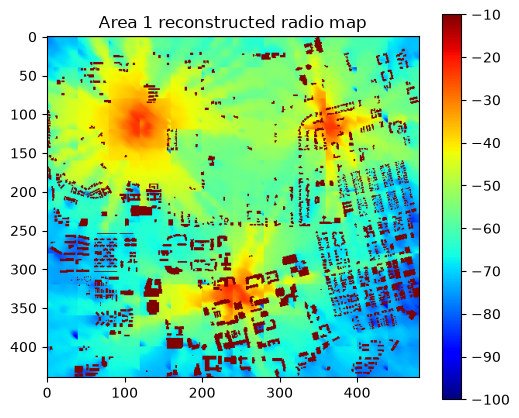

  area 2: features:   0%|          | 0/140 [00:00<?, ?it/s]

  area 2: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 2: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 2: final loss=0.0010, final val RMSE=3.7046


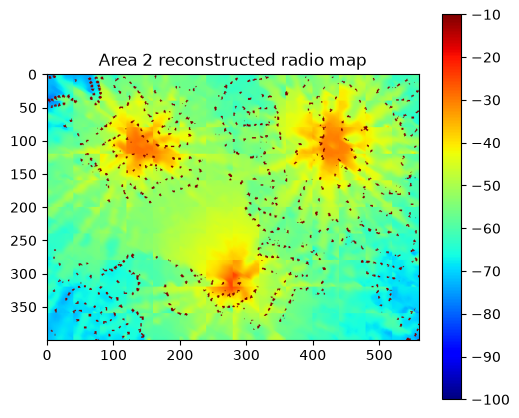

  area 3: features:   0%|          | 0/130 [00:00<?, ?it/s]

  area 3: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 3: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 3: final loss=0.0005, final val RMSE=2.6012


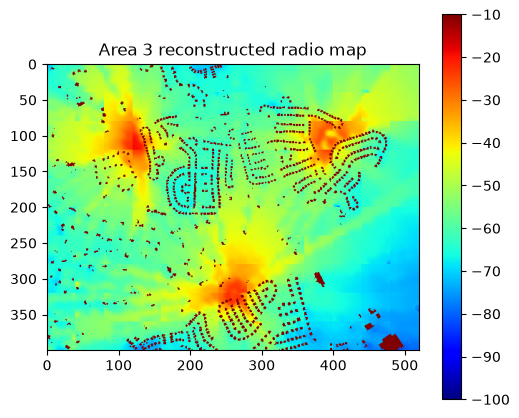

  area 4: features:   0%|          | 0/143 [00:00<?, ?it/s]

  area 4: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 4: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 4: final loss=0.0021, final val RMSE=6.1239


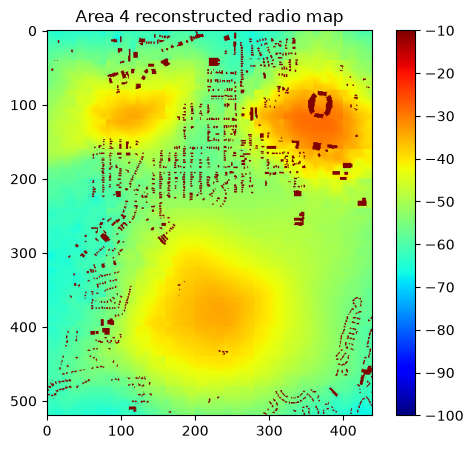

  area 5: features:   0%|          | 0/154 [00:00<?, ?it/s]

  area 5: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 5: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 5: final loss=0.0011, final val RMSE=3.0246


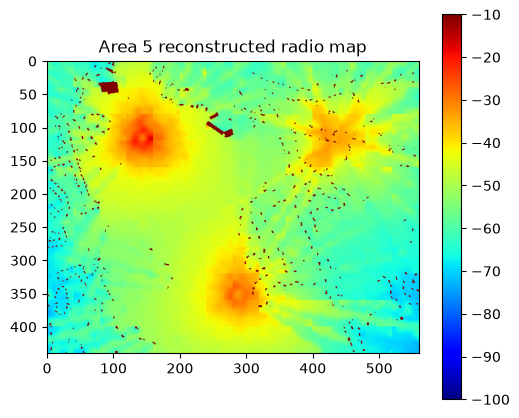

  area 6: features:   0%|          | 0/144 [00:00<?, ?it/s]

  area 6: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 6: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 6: final loss=0.0007, final val RMSE=2.6942


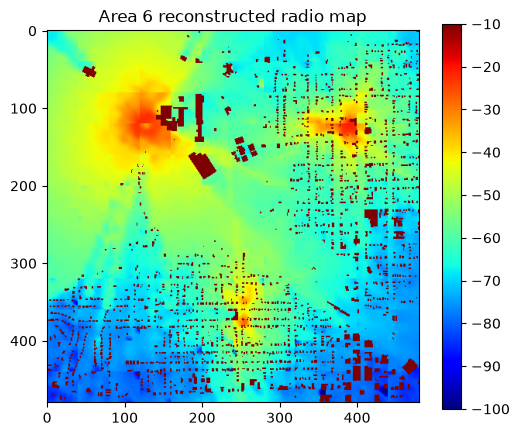

  area 7: features:   0%|          | 0/169 [00:00<?, ?it/s]

  area 7: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 7: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 7: final loss=0.0002, final val RMSE=2.1294


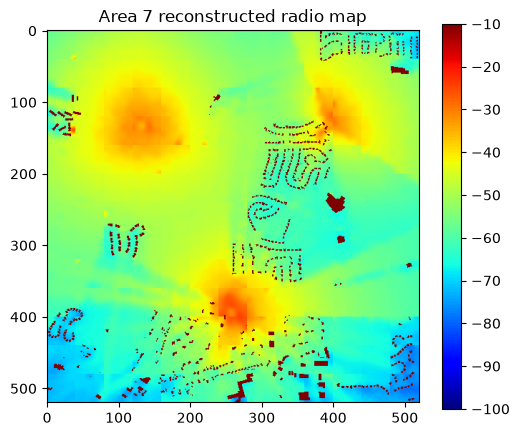

  area 8: features:   0%|          | 0/126 [00:00<?, ?it/s]

  area 8: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 8: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 8: final loss=0.0015, final val RMSE=4.2929


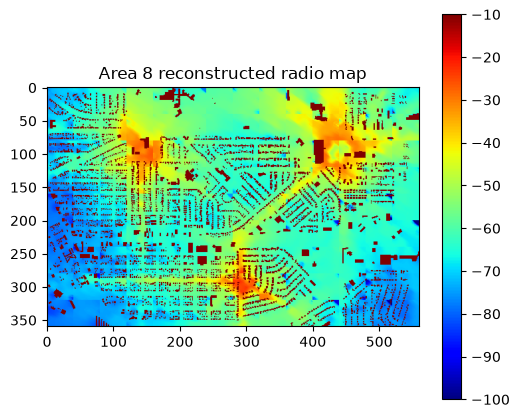

  area 9: features:   0%|          | 0/120 [00:00<?, ?it/s]

  area 9: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 9: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 9: final loss=0.0006, final val RMSE=3.1452


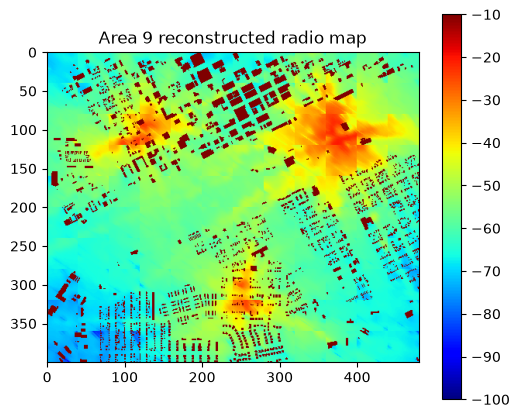

  area 10: features:   0%|          | 0/120 [00:00<?, ?it/s]

  area 10: adjacency:   0%|          | 0/5 [00:00<?, ?it/s]

  area 10: training:   0%|          | 0/250 [00:00<?, ?it/s]

area 10: final loss=0.0003, final val RMSE=2.8669


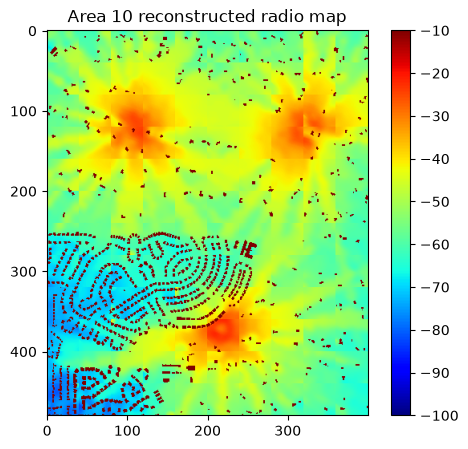

In [13]:
BlockX = BlockY = 40
axis = np.loadtxt(f'New_axis{BlockX}.txt', dtype=int)
Carry_Freq = np.array(Freq)
Train_Freq_Index = np.array([0,1,2,3])
Num_All_Freq = 5
Num_train_Freq = Num_Out_Freq = Num_In_Freq = 1
Input_Freq_Index = Out_Freq_Index = 0
Num_Node_Max = 1600
StationsPosition = np.loadtxt('stations_position.txt', dtype=int)

percent  = 0.05
masklv   = 1 - percent
method   = 1     # 0 Obsadj, 1 depadj, 2 Aroundadj, 3 TransmitterAdj
toupiao  = 0
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs   = 3 if QUICK_TEST else 250
lr       = 0.0005

area_range = range(1) if QUICK_TEST else range(10)

for AreaIndex in tqdm(area_range, desc="GAT: areas"):
    Num_All_Block   = int(axis[AreaIndex,0]*axis[AreaIndex,1]/BlockY/BlockX)
    Num_All_Block_X = int(axis[AreaIndex,1]/BlockX)
    if QUICK_TEST:
        Num_All_Block = min(Num_All_Block, QUICK_TEST_BLOCKS)
    Train_Percent = 0.5
    Num_Train_Block = int(Num_All_Block * Train_Percent)
    Num_Test_Block  = Num_All_Block - Num_Train_Block

    np.random.seed(0)
    Block_Index = np.arange(Num_All_Block)
    np.random.shuffle(Block_Index)

    N_Node = np.ones(Num_All_Block, dtype=int)
    for i in Block_Index:
        m, n = divmod(i, Num_All_Block_X)
        N_Node[i] = len(np.loadtxt(f'NodeFeatureStrength{BlockX}/{AreaIndex+1}/{Carry_Freq[0]}/{m+1}_{n+1}.txt', dtype=float))

    All_Mask = np.ones((Num_All_Block, Num_All_Freq, Num_Node_Max), dtype=int)
    np.random.seed(0)
    for i in Block_Index:
        train_mask0 = np.ones((Num_All_Freq, N_Node[i]), dtype=int)
        train_mask0[:, 0:int(N_Node[i]*masklv)] = 0
        for j in range(Num_All_Freq):
            np.random.shuffle(train_mask0[j, :])
        All_Mask[i, :, 0:N_Node[i]] = train_mask0

    Num_Axis_Feature = 2
    Num_Feature = Num_Axis_Feature + Num_In_Freq + Num_Out_Freq + Num_In_Freq
    All_Feature = np.ones((Num_All_Block, Num_Node_Max, Num_Feature, Num_All_Freq))

    for i in tqdm(Block_Index, desc=f"  area {AreaIndex+1}: features", leave=False):
        m, n = divmod(i, Num_All_Block_X)
        for k in range(Num_All_Freq):
            axis_data = np.loadtxt(f'NodeFeatureAxis{BlockX}/{AreaIndex+1}/{Carry_Freq[0]}/{m+1}_{n+1}.txt', dtype=float).T
            All_Feature[i, 0:N_Node[i], 0:Num_Axis_Feature, k] = axis_data
            All_Feature[i, 0:N_Node[i], 0, k] = (All_Feature[i, 0:N_Node[i], 0, k] + 40*m) / (int(axis[AreaIndex,0]/BlockY)) / 40
            All_Feature[i, 0:N_Node[i], 1, k] = (All_Feature[i, 0:N_Node[i], 1, k] + 40*n) / Num_All_Block_X / 40
            for j in range(Num_In_Freq):
                strength = np.loadtxt(f'NodeFeatureStrength{BlockX}/{AreaIndex+1}/{Carry_Freq[j]}/{m+1}_{n+1}.txt', dtype=float)
                All_Feature[i, 0:N_Node[i], Num_Axis_Feature+Num_In_Freq+Num_Out_Freq+j, k] = (All_Mask[i,k,0:N_Node[i]] * strength) / (-100)

    All_Y = np.ones((Num_All_Block, Num_Node_Max, Num_All_Freq))
    for i in Block_Index:
        m, n = divmod(i, Num_All_Block_X)
        for j in range(Num_All_Freq):
            All_Y[i, 0:N_Node[i], j] = np.loadtxt(f'NodeFeatureStrength{BlockX}/{AreaIndex+1}/{Carry_Freq[j]}/{m+1}_{n+1}.txt', dtype=float) / (-100)

    Spatial_Depth_Map1 = np.loadtxt(f'LossProb/{AreaIndex+1}/1.txt', dtype=float)
    Spatial_Depth_Map2 = np.loadtxt(f'LossProb/{AreaIndex+1}/2.txt', dtype=float)
    Spatial_Depth_Map3 = np.loadtxt(f'LossProb/{AreaIndex+1}/3.txt', dtype=float)
    SFDepth = np.stack([Spatial_Depth_Map1, Spatial_Depth_Map2, Spatial_Depth_Map3])

    All_Adj = np.ones((Num_All_Freq, Num_All_Block, Num_Node_Max, Num_Node_Max), dtype=np.int8)
    suoyin_cache = {}
    for j in tqdm(range(Num_All_Freq), desc=f"  area {AreaIndex+1}: adjacency", leave=False):
        chayuzhi = chayufenzi / math.log(Frequency[j], 10)
        for i in Block_Index:
            m, n = divmod(i, Num_All_Block_X)
            if method == 0:
                All_Adj[j,i,0:N_Node[i],0:N_Node[i]] = np.loadtxt(f'ObstructionAdj_6_40/{AreaIndex+1}/{m+1}_{n+1}.txt', dtype=int)
            elif method == 1:
                if i not in suoyin_cache:
                    suoyin_cache[i] = np.loadtxt(f'NodeFeatureAxis{BlockX}/{AreaIndex+1}/{Carry_Freq[0]}/{m+1}_{n+1}.txt', dtype=int)
                suoyin = suoyin_cache[i]
                All_Adj[j,i,0:N_Node[i],0:N_Node[i]] = compute_adj_vectorized(suoyin, SFDepth, chayuzhi, dcor)
            elif method == 2:
                All_Adj[j,i,0:N_Node[i],0:N_Node[i]] = np.loadtxt(f'AroundAdj40/{AreaIndex+1}/{m+1}_{n+1}.txt', dtype=int)
            elif method == 3:
                All_Adj[j,i,0:N_Node[i],0:N_Node[i]] = np.loadtxt(f'TransmitterAdj40/{AreaIndex+1}/{m+1}_{n+1}.txt', dtype=int)
            adj0 = np.eye(N_Node[i], dtype=np.int8)
            All_Adj[j,i,0:N_Node[i],0:N_Node[i]] = adj0 + All_Adj[j,i,0:N_Node[i],0:N_Node[i]]

    model = GAT(Num_Feature, Num_Out_Freq).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.MSELoss()

    loss0 = np.ones(epochs)
    acc0  = np.ones(epochs)
    epoch_bar = tqdm(range(epochs), desc=f"  area {AreaIndex+1}: training")

    for epoch in epoch_bar:
        model.train()
        for i in Block_Index[0:Num_Train_Block]:
            for k in range(Num_train_Freq):
                Feature = All_Feature[i, 0:N_Node[i], :, k].copy()
                Feature[:, Num_Axis_Feature] = Carry_Freq[Train_Freq_Index[k]] / 5750
                Feature[:, Num_Axis_Feature+Num_In_Freq] = Carry_Freq[Out_Freq_Index] / 5750
                Adj = torch.FloatTensor(All_Adj[Train_Freq_Index[k], i, 0:N_Node[i], 0:N_Node[i]])
                Feature = torch.FloatTensor(Feature).requires_grad_(True)
                OutAdj = torch.FloatTensor(All_Adj[0, i, 0:N_Node[i], 0:N_Node[i]])
                optimizer.zero_grad()
                Pred = model(Feature.to(device), Adj.to(device), OutAdj.to(device))
                if Carry_Freq[Train_Freq_Index[k]] == Carry_Freq[Out_Freq_Index]:
                    mask = torch.tensor(All_Mask[i, Out_Freq_Index, 0:N_Node[i]]).bool()
                    Mask_Pred = Pred[mask]
                    Mask_Real = All_Y[i, 0:N_Node[i], Out_Freq_Index][mask]
                else:
                    Mask_Pred = Pred
                    Mask_Real = All_Y[i, 0:N_Node[i], Out_Freq_Index]
                Mask_Real = torch.FloatTensor(Mask_Real)
                loss = loss_function(Mask_Pred[:, 0].to(device), Mask_Real.to(device))
                loss.backward()
                optimizer.step()
        loss0[epoch] = loss.item()

        model.eval()
        if epoch % 10 == 0 or epoch == epochs - 1:
            mse = 0
            for i in Block_Index[Num_Train_Block:Num_All_Block]:
                Feature = All_Feature[i, 0:N_Node[i], :, Input_Freq_Index].copy()
                Feature[:, Num_Axis_Feature] = Carry_Freq[Input_Freq_Index] / 5750
                Feature[:, Num_Axis_Feature+Num_In_Freq] = Carry_Freq[Out_Freq_Index] / 5750
                Adj = torch.FloatTensor(All_Adj[Input_Freq_Index, i, 0:N_Node[i], 0:N_Node[i]])
                Feature = torch.FloatTensor(Feature).requires_grad_(True)
                OutAdj = torch.FloatTensor(All_Adj[Out_Freq_Index, i, 0:N_Node[i], 0:N_Node[i]])
                Pred = model(Feature.to(device), Adj.to(device), OutAdj.to(device))
                mask = torch.tensor(1 - All_Mask[i, Out_Freq_Index, 0:N_Node[i]]).bool()
                Mask_Pred = Pred[mask, 0]
                Mask_Real = All_Y[i, 0:N_Node[i], Out_Freq_Index][mask]
                mse = np.sqrt(mse*mse + mean_squared_error(Mask_Pred.cpu().detach().numpy(), Mask_Real))
            acc0[epoch] = 100 * mse / np.sqrt(Num_Test_Block)
            epoch_bar.set_postfix(loss=f"{loss0[epoch]:.4f}", val_rmse=f"{acc0[epoch]:.4f}")

    tqdm.write(f"area {AreaIndex+1}: final loss={loss0[-1]:.4f}, final val RMSE={acc0[epochs-1]:.4f}")

    # Reconstruct the full map for this area for visualization
    model.eval()
    Num_All_Block_Y = int(axis[AreaIndex,0]/BlockY)
    zongtu = np.ones((Num_All_Block_X*40, Num_All_Block_Y*40), dtype=float)
    for i in Block_Index:
        m, n = divmod(i, Num_All_Block_X)
        Feature = All_Feature[i, 0:N_Node[i], :, Input_Freq_Index].copy()
        Feature[:, Num_Axis_Feature] = Carry_Freq[Input_Freq_Index] / 5750
        Feature[:, Num_Axis_Feature+Num_In_Freq] = Carry_Freq[Out_Freq_Index] / 5750
        Adj = torch.FloatTensor(All_Adj[Input_Freq_Index, i, 0:N_Node[i], 0:N_Node[i]])
        Feature = torch.FloatTensor(Feature).requires_grad_(True)
        OutAdj = torch.FloatTensor(All_Adj[Out_Freq_Index, i, 0:N_Node[i], 0:N_Node[i]])
        Pred = model(Feature.to(device), Adj.to(device), OutAdj.to(device))
        axistest = np.loadtxt(f'NodeFeatureAxis{BlockX}/{AreaIndex+1}/{Carry_Freq[0]}/{m+1}_{n+1}.txt', dtype=int).T
        u = axistest[0:N_Node[i], 0] + 40*m
        v = axistest[0:N_Node[i], 1] + 40*n
        zongtu[v, u] = Pred[:, 0].cpu().detach().numpy() * (-100)
    zongtu[np.where(zongtu == 1)] = 0

    plt.figure(figsize=(6,5))
    plt.imshow(zongtu.T, cmap='jet', norm=plt.Normalize(vmin=-100, vmax=-10))
    plt.colorbar()
    plt.title(f"Area {AreaIndex+1} reconstructed radio map")
    plt.show()